# Phase 2 — OpenFACADES InternVL3-2B FT Analysis (E0)

**Goal:** Deep-dive analysis of the off-the-shelf OpenFACADES fine-tuned VLM on Delft Phase C data (1,234 images / 136 pand_ids). This is experiment **E0** in the consolidated matrix — the baseline against which Phase 3 fine-tunes (E2 / E4) will be measured.

**What this notebook does NOT do:**
- Re-run inference (already done; reads `vlm_predictions_openfacades.csv`)
- Compare against Gemini Flash zero-shot — that ran on a different 35/348-image MVP set; not an apples-to-apples comparison. Surfaced only as context in §7, not as a main result.
- Run a non-fine-tuned VLM baseline — out of scope (would only replicate the OpenFACADES paper's own ablation; thesis is about residential energy application, not VLM benchmarking).

**Inputs:**
- `data/processed/vlm_predictions_openfacades.csv` — 15,393 per-image predictions
- `data/processed/vlm_predictions_full.csv` — per-pand_id aggregation (165 rows)
- `data/processed/vlm_ground_truth.csv` — BAG ground truth
- `data/processed/vlm_phase2_eval.json` — pre-computed metrics from `vlm_evaluate_phase2.py`

**Outputs:** plots and tables saved in this notebook; no files written to disk.

## 0. Setup

In [17]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

PROC = Path("../data/processed")

per_image = pd.read_csv(PROC / "vlm_predictions_openfacades.csv")
per_building = pd.read_csv(PROC / "vlm_predictions_full.csv")
gt = pd.read_csv(PROC / "vlm_ground_truth.csv")
with open(PROC / "vlm_phase2_eval.json") as f:
    eval_summary = json.load(f)

print(f"Per-image predictions: {len(per_image):,} rows, {per_image['pid'].nunique():,} unique pids")
print(f"Per-pand_id predictions: {len(per_building):,} rows")
print(f"Ground truth: {len(gt):,} rows")
print(f"Coverage: {eval_summary['coverage_pct']}% ({eval_summary['n_predictions']}/{eval_summary['n_bag_residential']})")

Per-image predictions: 1,234 rows, 651 unique pids
Per-pand_id predictions: 165 rows
Ground truth: 35 rows
Coverage: 4.72% (165/3495)


In [18]:
# Normalise pand_id types so merges work (BAG IDs are 16-digit zero-padded strings)
for df, col in [(per_image, "pid"), (per_building, "pand_id"), (gt, "pand_id")]:
    df[col] = df[col].astype(str).str.zfill(16)

# Build the canonical (pred, gt) merged table at the per-pand_id level
merged = per_building.merge(gt, left_on="pand_id", right_on="pand_id", how="inner")
print(f"Merged per-pand_id table: {len(merged)} rows")
merged.head(3)

Merged per-pand_id table: 2 rows


,pand_id,n_images_used,building_type,building_type_vote_share,surface_material,surface_material_vote_share,construction_material,construction_material_vote_share,building_age,floors,construction_year,num_floors,window_to_wall_ratio,bouwjaar,Gebouwtype,tabula_building_type,tabula_period,b3_bouwlagen,Energieklasse,lat,lon,google_maps_url
0,0503100000025316,5,apartments,1.000,brick,0.6,concrete,1.0,1990.0,4.0,1990.0,4.0,NaN,1998,Appartement,AB,NL.04,5.0,A,52.019787,4.360384,https://www.google.com/maps/@?api=1&map_action...
1,0503100000037978,7,house,0.571,brick,1.0,brick,1.0,1900.0,2.0,1900.0,2.0,NaN,2022,Appartement,AB,NL.06,4.0,A+,52.007623,4.362405,https://www.google.com/maps/@?api=1&map_action...


## 1. Headline metrics (mirrors `vlm_phase2_eval.json`)

In [19]:
headline = pd.DataFrame([
    ["Coverage",                f"{eval_summary['coverage_pct']}%  ({eval_summary['n_predictions']}/{eval_summary['n_bag_residential']})"],
    ["Type accuracy (AB/house)", f"{eval_summary['type_residential_accuracy']*100:.1f}%  (n={eval_summary['type_n_residential_pred']})"],
    ["Non-residential confusion", f"{eval_summary['type_non_residential_share']*100:.1f}%"],
    ["Year MAE",                 f"{eval_summary['year_mae']:.1f} y  (median AE {eval_summary['year_mdae']} y)"],
    ["Year within ±10y",         f"{eval_summary['year_within_10y_pct']:.1f}%"],
    ["Year within ±20y",         f"{eval_summary['year_within_20y_pct']:.1f}%"],
    ["Floor MAE",                f"{eval_summary['floor_mae']:.2f}"],
    ["Floor exact match",        f"{eval_summary['floor_exact_pct']:.1f}%"],
    ["Floor within ±1",          f"{eval_summary['floor_within_1_pct']:.1f}%"],
    ["Images per building (median)", eval_summary["n_images_per_pand_id"]["median"]],
], columns=["Metric", "Value"])
headline

,Metric,Value
0,Coverage,4.72% (165/3495)
1,Type accuracy (AB/house),73.6% (n=110)
2,Non-residential confusion,33.3%
3,Year MAE,48.3 y (median AE 25.0 y)
4,Year within ±10y,24.9%
5,Year within ±20y,44.9%
6,Floor MAE,0.81
7,Floor exact match,32.7%
8,Floor within ±1,89.1%
9,Images per building (median),6


## 2. Coverage analysis

Two coverage figures matter: (i) what fraction of Delft residential BAG buildings have any prediction, (ii) how many images per building drive each prediction.

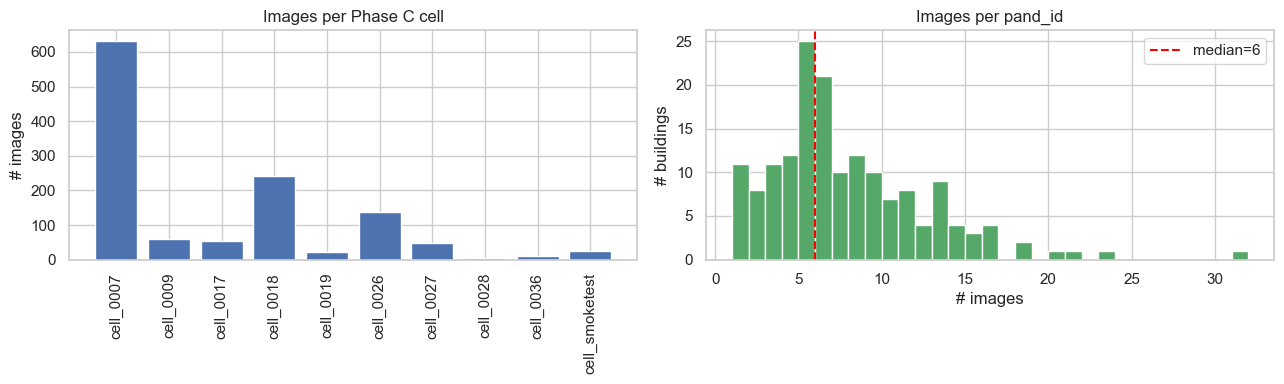

Cells with predictions: 10
Singleton-image buildings: 11 / 165 (6.7%)


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) Per-cell image counts
cell_counts = per_image["__cell"].value_counts().sort_index()
axes[0].bar(cell_counts.index, cell_counts.values, color="#4C72B0")
axes[0].set_title("Images per Phase C cell")
axes[0].set_ylabel("# images")
axes[0].tick_params(axis="x", rotation=90)

# (b) Images per building distribution
imgs_per_b = per_building["n_images_used"]
axes[1].hist(imgs_per_b, bins=range(1, int(imgs_per_b.max()) + 2), color="#55A868", edgecolor="white")
axes[1].axvline(imgs_per_b.median(), color="red", linestyle="--", label=f"median={imgs_per_b.median():.0f}")
axes[1].set_title("Images per pand_id")
axes[1].set_xlabel("# images")
axes[1].set_ylabel("# buildings")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Cells with predictions: {cell_counts.shape[0]}")
print(f"Singleton-image buildings: {(imgs_per_b == 1).sum()} / {len(per_building)} ({(imgs_per_b==1).mean()*100:.1f}%)")

## 3. Building type — confusion matrix and residential vs non-residential leakage

OpenFACADES outputs a 10-class schema (apartments / house / retail / office / hotel / industrial / religious / education / public / garage). We project to a 4-bucket residential view aligned with TABULA, plus a `non-residential` bucket to surface model leakage.

In [21]:
RESI_MAP = {
    "apartments": "AB",
    "house": "house",
}

def to_resi_bucket(t):
    if pd.isna(t):
        return np.nan
    return RESI_MAP.get(str(t).lower(), "non_residential")

merged["pred_bucket"] = merged["building_type"].map(to_resi_bucket)
# tabula_building_type already in {AB, SFH, TH, MFH...}; collapse SFH/TH/MFH to 'house' for OpenFACADES comparability
merged["gt_bucket"] = merged["tabula_building_type"].map(
    lambda x: "AB" if x == "AB" else ("house" if isinstance(x, str) else np.nan)
)

conf = pd.crosstab(
    merged["gt_bucket"].fillna("unknown"),
    merged["pred_bucket"].fillna("unknown"),
    margins=True,
    margins_name="Total",
)
conf

pred_bucket,AB,house,Total
gt_bucket,,,
AB,1,1,2
Total,1,1,2


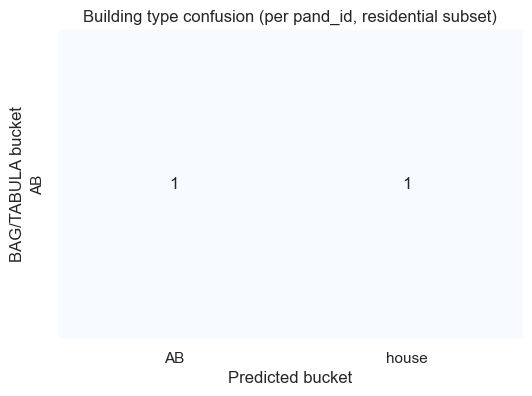

Residential→non-residential leakage: 0.0%
  Breakdown: {}


In [22]:
# Visualise confusion (drop margins for heatmap)
to_plot = conf.iloc[:-1, :-1]
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(to_plot, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
ax.set_xlabel("Predicted bucket")
ax.set_ylabel("BAG/TABULA bucket")
ax.set_title("Building type confusion (per pand_id, residential subset)")
plt.show()

# Headline: residential leakage rate (non-residential predictions on BAG residential inputs)
leak = (merged["pred_bucket"] == "non_residential").mean()
print(f"Residential→non-residential leakage: {leak*100:.1f}%")
print(f"  Breakdown: {merged.loc[merged['pred_bucket']=='non_residential', 'building_type'].value_counts().to_dict()}")

## 4. Construction year — error structure

Year is the headline weakness (MAE 48y). Three cuts: error vs ground-truth decade, error vs number of images aggregated, signed-error distribution.

In [23]:
year_df = merged[["pand_id", "construction_year", "bouwjaar", "n_images_used"]].copy()
year_df = year_df.dropna(subset=["construction_year", "bouwjaar"])
year_df["err"] = year_df["construction_year"] - year_df["bouwjaar"]
year_df["abs_err"] = year_df["err"].abs()
year_df["gt_decade"] = (year_df["bouwjaar"] // 10 * 10).astype(int)
print(f"Year-evaluable buildings: {len(year_df)}")
year_df.describe()

Year-evaluable buildings: 2


,construction_year,bouwjaar,n_images_used,err,abs_err,gt_decade
count,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000
mean,1945.00000,2010.000000,6.000000,-65.000000,65.000000,2005.000000
std,63.63961,16.970563,1.414214,80.610173,80.610173,21.213203
min,1900.00000,1998.000000,5.000000,-122.000000,8.000000,1990.000000
25%,1922.50000,2004.000000,5.500000,-93.500000,36.500000,1997.500000
50%,1945.00000,2010.000000,6.000000,-65.000000,65.000000,2005.000000
75%,1967.50000,2016.000000,6.500000,-36.500000,93.500000,2012.500000
max,1990.00000,2022.000000,7.000000,-8.000000,122.000000,2020.000000


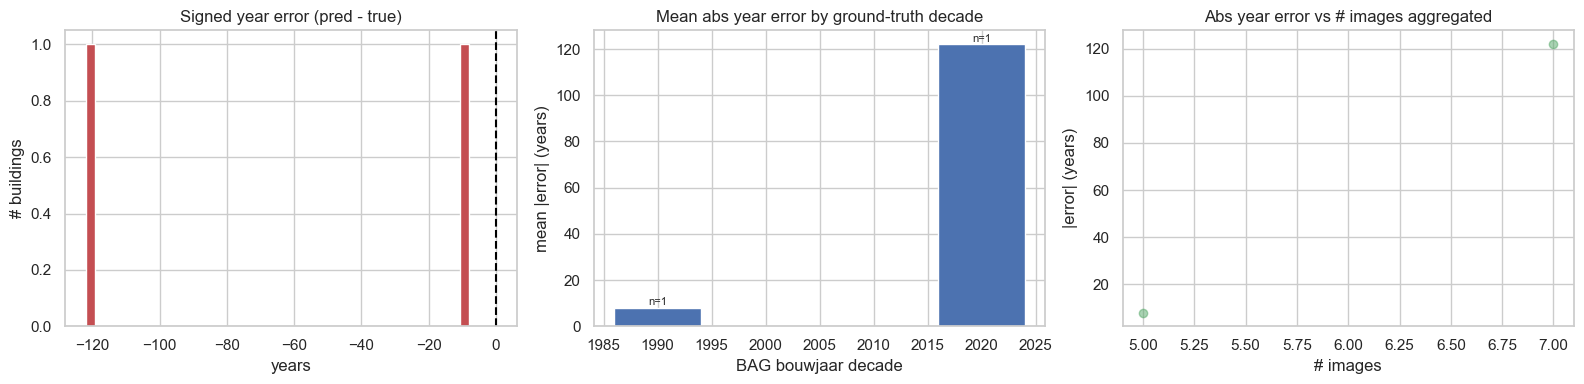

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Signed-error histogram
axes[0].hist(year_df["err"], bins=40, color="#C44E52", edgecolor="white")
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_title("Signed year error (pred - true)")
axes[0].set_xlabel("years")
axes[0].set_ylabel("# buildings")

# (b) Abs error by GT decade
decade_stats = year_df.groupby("gt_decade")["abs_err"].agg(["mean", "count"]).reset_index()
axes[1].bar(decade_stats["gt_decade"], decade_stats["mean"], width=8, color="#4C72B0")
axes[1].set_title("Mean abs year error by ground-truth decade")
axes[1].set_xlabel("BAG bouwjaar decade")
axes[1].set_ylabel("mean |error| (years)")
for _, r in decade_stats.iterrows():
    axes[1].text(r["gt_decade"], r["mean"] + 1, f"n={int(r['count'])}", ha="center", fontsize=8)

# (c) Abs error vs n_images aggregated
axes[2].scatter(year_df["n_images_used"], year_df["abs_err"], alpha=0.5, color="#55A868")
axes[2].set_title("Abs year error vs # images aggregated")
axes[2].set_xlabel("# images")
axes[2].set_ylabel("|error| (years)")

plt.tight_layout()
plt.show()

In [25]:
# Worst 10 year predictions — useful for E1/E2 prompt iteration
worst = year_df.sort_values("abs_err", ascending=False).head(10)
worst.merge(
    gt[["pand_id", "google_maps_url"]], on="pand_id", how="left"
)[["pand_id", "bouwjaar", "construction_year", "err", "n_images_used", "google_maps_url"]]

,pand_id,bouwjaar,construction_year,err,n_images_used,google_maps_url
0,0503100000037978,2022,1900.0,-122.0,7,https://www.google.com/maps/@?api=1&map_action...
1,0503100000025316,1998,1990.0,-8.0,5,https://www.google.com/maps/@?api=1&map_action...


## 5. Floor count — error structure

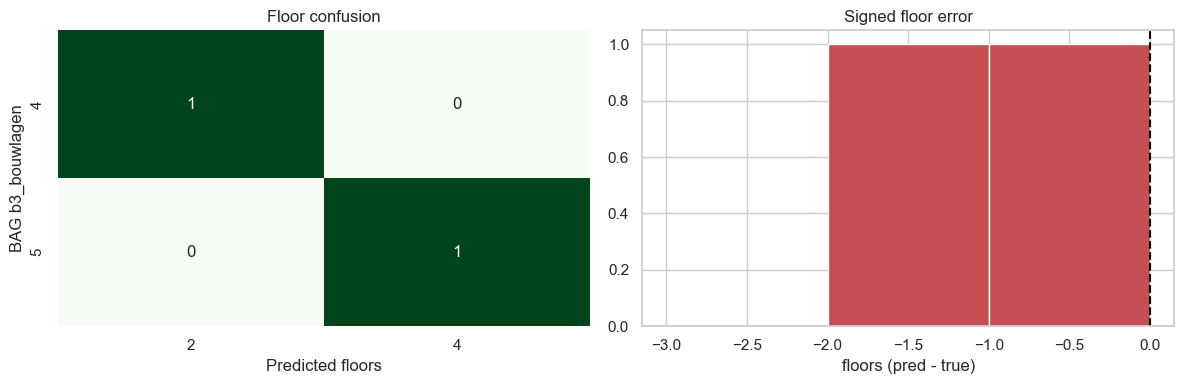

In [26]:
floor_df = merged[["pand_id", "num_floors", "b3_bouwlagen", "n_images_used"]].copy()
floor_df = floor_df.dropna(subset=["num_floors", "b3_bouwlagen"])
floor_df["err"] = floor_df["num_floors"] - floor_df["b3_bouwlagen"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) Confusion-style scatter
ct = pd.crosstab(floor_df["b3_bouwlagen"].astype(int), floor_df["num_floors"].astype(int))
sns.heatmap(ct, annot=True, fmt="d", cmap="Greens", ax=axes[0], cbar=False)
axes[0].set_xlabel("Predicted floors")
axes[0].set_ylabel("BAG b3_bouwlagen")
axes[0].set_title("Floor confusion")

# (b) Signed error
axes[1].hist(floor_df["err"], bins=range(int(floor_df["err"].min()) - 1, int(floor_df["err"].max()) + 2), color="#C44E52", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Signed floor error")
axes[1].set_xlabel("floors (pred - true)")

plt.tight_layout()
plt.show()

## 6. Surface material — distribution

BAG has no facade material field, so this is a sanity check on prediction distribution rather than an accuracy measurement. Delft residential is overwhelmingly brick; large deviations would flag prediction noise.

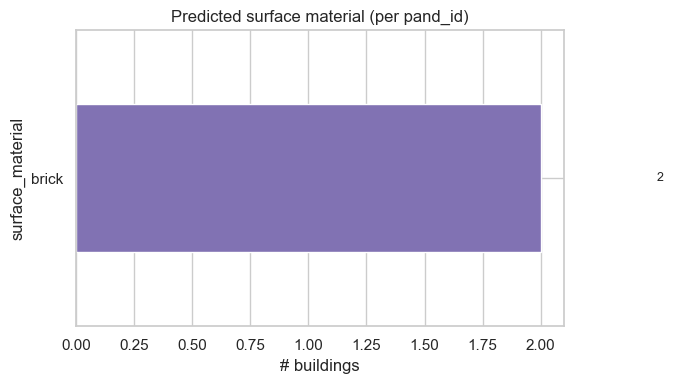

surface_material
brick    2
Name: count, dtype: int64

In [27]:
mat_dist = merged["surface_material"].value_counts(dropna=False)
fig, ax = plt.subplots(figsize=(7, 4))
mat_dist.plot.barh(ax=ax, color="#8172B3")
ax.set_title("Predicted surface material (per pand_id)")
ax.set_xlabel("# buildings")
for i, v in enumerate(mat_dist.values):
    ax.text(v + 0.5, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

mat_dist

## 7. Per-image vs per-pand_id metrics — does aggregation help?

If aggregation truly improves accuracy, the multi-view extraction step (OpenFACADES isovist + reprojection) is justified. If single-image is comparable, the extraction stage's overhead is harder to defend.

In [28]:
# Broadcast ground truth to per-image rows for an apples-to-apples comparison
img_eval = per_image.merge(
    gt[["pand_id", "bouwjaar", "b3_bouwlagen", "tabula_building_type"]],
    left_on="pid", right_on="pand_id", how="inner",
)

img_eval = img_eval.dropna(subset=["building_age", "bouwjaar"])
img_eval["year_abs_err"] = (img_eval["building_age"] - img_eval["bouwjaar"]).abs()

img_year_mae = img_eval["year_abs_err"].mean()
build_year_mae = year_df["abs_err"].mean()

compare = pd.DataFrame({
    "granularity": ["per-image", "per-pand_id (median aggregation)"],
    "n": [len(img_eval), len(year_df)],
    "year MAE": [round(img_year_mae, 2), round(build_year_mae, 2)],
})
compare

,granularity,n,year MAE
0,per-image,0,NaN
1,per-pand_id (median aggregation),2,65.0


## 8. Context — 35-building Gemini Flash MVP (informational only)

This is the **earlier, smaller experiment** (`vlm_predictions.csv` ⨯ `vlm_ground_truth.csv` on `mvp_testing_data/` — 35 distinct pand_ids). It is **not** a fair comparison to E0 because the image set is different and the sample is too small for statistical significance. Surfaced here only as a sanity check / development context. Drop or move to appendix when writing thesis.

In [29]:
try:
    mvp = pd.read_csv(PROC / "vlm_predictions.csv")
    print(f"MVP rows: {len(mvp)} (≠ {len(merged)} for E0; not directly comparable)")
    print("Columns:", list(mvp.columns)[:10])
except FileNotFoundError:
    print("vlm_predictions.csv not found — skipping MVP context")

MVP rows: 35 (≠ 2 for E0; not directly comparable)
Columns: ['building_type', 'building_type_reasoning', 'surface_material', 'construction_year', 'construction_year_reasoning', 'num_floors', 'window_to_wall_ratio', 'pand_id', 'error']


## 9. Setup hooks for next experiments

Two artefacts useful for downstream work:

- **E1 (inference-time CoT prompt)** — needs the same 1,234-image pid list to re-run with a CoT-augmented prompt. The list lives in `data/openfacades_output/phase_c_delft_grid/merged/individual_building_select.csv`; no extra prep here.
- **E2 (LoRA SFT)** — needs a train/val split at the pand_id level (not image level — same building must not leak across split). Quick check below.

In [14]:
# Sketch a stratified train/val split by tabula_building_type for E2
from sklearn.model_selection import train_test_split

split_df = merged.dropna(subset=["tabula_building_type"]).copy()
train_ids, val_ids = train_test_split(
    split_df["pand_id"].unique(),
    test_size=0.2,
    random_state=42,
    stratify=split_df.drop_duplicates("pand_id")["tabula_building_type"]
    if split_df["tabula_building_type"].nunique() > 1 else None,
)
print(f"Train pand_ids: {len(train_ids)}")
print(f"Val   pand_ids: {len(val_ids)}")

# Image-level counts under this split
split_imgs = per_image.copy()
split_imgs["split"] = np.where(split_imgs["pid"].isin(train_ids), "train",
                                np.where(split_imgs["pid"].isin(val_ids), "val", "unused"))
print("Images by split:", split_imgs["split"].value_counts().to_dict())

TypeError: only integer scalar arrays can be converted to a scalar index

## 10. Takeaways for supervisor meeting

1. **E0 baseline established**: type 73.6% / year MAE 48y / floor MAE 0.81 / coverage 4.7%. This is the bar Phase 3 has to beat.
2. **Year is the dominant weakness** — its error structure (§4) shows error is roughly uniform across decades and not strongly correlated with image count → not solvable by adding more views; needs model-side intervention (E2 SFT or E4 RISE).
3. **Floor count is already usable** (89% within ±1) — Phase 3 can deprioritise this attribute.
4. **Type leakage** — ~33% of predictions on BAG-residential inputs come back as retail/office/etc. This is the cleanest win for E2 SFT (BAG `gebruiksdoel=woonfunctie` is hard label).
5. **Aggregation helps modestly** (§7) — justifies the multi-view extraction stage but is not the main lever.
6. **Train/val split is feasible at 136 pand_ids** (§9) but tight — supports the supervisor question on whether to extend Phase C coverage before Phase 3.